### 1. Preparación de los datos

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler

* (a) Carga y preparación de los datos: Trabajaremos con el Breast Cancer Wisconsin Dataset. Este conjunto de datos es un estándar en el
aprendizaje automático clínico y fue descargado directamente desde la librería scikit-learn

In [3]:
###Primero cargamos los datos 
data = load_breast_cancer()
dataframe = pd.DataFrame(data.data, columns=data.feature_names)
dataframe_breast = dataframe.loc[:,["mean radius", "mean texture"]]

print(dataframe_breast.shape)

print(dataframe_breast.head())

(569, 2)
   mean radius  mean texture
0        17.99         10.38
1        20.57         17.77
2        19.69         21.25
3        11.42         20.38
4        20.29         14.34


* (b) Estandarización

In [4]:
# Estandarización de los datos
# manualmente sería restar la media y dividir por la desviación estándar para cada columna
# X_manual = (dataframe_breast - dataframe_breast.mean()) / dataframe_breast.std()

# Con StandardScaler de sklearn
scaler = StandardScaler()
X = scaler.fit_transform(dataframe_breast)

y_target = data.target


* (c) SVM requiere que las clases sean -1 y 1 (no 0 y 1) para que el signo 
multiplique correctamente la frontera de decisión.


In [5]:
y = np.where(y_target == 0, -1, 1)

print(f"Dimensión de X: {X.shape}")
print(f"Primeros 5 valores de y ajustados: {y[:5]}")

Dimensión de X: (569, 2)
Primeros 5 valores de y ajustados: [-1 -1 -1 -1 -1]


### 2. Formulación y Derivación Analítica

Aqui aplicaremos el cáculo multivariado visto en la última clase

* Función objetivo:

La función objetivo (costo) que debemos minimizar consta de dos partes: la maximización del margen y la penalización por errores. Matemáticamente se define como:

$$J(w, b) = \underbrace{\frac{1}{2}||w||^2}_{\text{Margen}} + \underbrace{C \frac{1}{N} \sum_{i=1}^{N} \max(0, 1 - y_i(w^T x_i + b))}_{\text{Penalización Hinge}}$$

**Donde:**
* $w$ y $b$: Son los parámetros de nuestro hiperplano (pesos y sesgo).
* $\frac{1}{2}||w||^2$: Al minimizar esto, estamos maximizando geométricamente la distancia (el "callejón") entre las dos clases.
* $C$: Es el hiperparámetro de regularización que controla qué tanto "castigamos" los errores.
* $\max(0, 1 - y_i(w^T x_i + b))$: Es la Pérdida Bisagra (Hinge Loss). Solo arroja un valor mayor a cero si un punto cruza la línea de seguridad de su clase.

(b) y (c): Derivación Analítica y Gradientes por Tramos

Para encontrar el mínimo de la función de costo $J(w, b)$, necesitamos aplicar el Descenso de Gradiente. Esto requiere calcular las derivadas parciales de $J$ con respecto a los pesos ($w$) y al sesgo ($b$): $\frac{\partial J}{\partial w}$ y $\frac{\partial J}{\partial b}$.

El principal reto matemático aquí es la función **Pérdida Bisagra (Hinge Loss)**: $\max(0, 1 - y_i(w^T x_i + b))$. 
Esta función tiene un "quiebre" en cero, lo que significa que **no es diferenciable en todo su dominio**. Para resolver esto, aplicamos el concepto de **derivada por tramos (subgradiente)**, evaluando la condición de cada punto de datos $i$:

#### Condición 1: El punto no viola el margen (Clasificación Perfecta)
Si el punto está correctamente clasificado y se encuentra fuera de la zona de penalización, se cumple que $y_i(w^T x_i + b) \ge 1$. 
En este caso, $1 - y_i(w^T x_i + b) \le 0$, por lo que la función $\max(0, \text{negativo})$ devuelve `0`.
* **Derivada respecto a $w$:** $0$
* **Derivada respecto a $b$:** $0$

#### Condición 2: El punto viola el margen (Error o dentro de la banda)
Si el punto entra en el margen o está mal clasificado, se cumple que $y_i(w^T x_i + b) < 1$.
Aquí la función $\max$ se "activa" y devuelve $1 - y_i(w^T x_i + b)$. Aplicando la regla de la cadena, derivamos esta expresión:
* **Derivada respecto a $w$:** $-y_i x_i$
* **Derivada respecto a $b$:** $-y_i$

---

### Ecuaciones Finales del Gradiente

Al juntar la derivada del término de regularización $\left( \frac{\partial}{\partial w} \frac{1}{2}||w||^2 = w \right)$ con la sumatoria de los errores por tramos, obtenemos nuestras ecuaciones analíticas finales para la actualización de los pesos. 

Dado un conjunto de $N$ datos, los gradientes promediados son:

**Gradiente respecto a los pesos ($w$):**
$$\frac{\partial J}{\partial w} = w - \frac{C}{N} \sum_{i \in \text{Violaciones}} y_i x_i$$

**Gradiente respecto al sesgo ($b$):**
$$\frac{\partial J}{\partial b} = - \frac{C}{N} \sum_{i \in \text{Violaciones}} y_i$$

*(Nota: La sumatoria solo incluye a los índices $i$ de los puntos que cayeron en la **Condición 2**, ya que los puntos de la Condición 1 aportan cero matemáticamente).*

### 3.  Implementación de la Optimización

A continuación, Programamos los algoritmos para minimizar la función de costo calculada en el paso anterior. Para esta etapa el parámetro de penalización es C = 1

In [6]:
# --- Gradiente Descendente (Batch GD) ---
def gradient_descent(X, y, C=1.0, lr=0.01, epochs=1000): # un epoch representa una pasada completa por todo el conjunto de datos de entrenamiento
    N, d = X.shape # N = cantidad de pacientes (filas), d = cantidad de características (columnas, que son 2)
    # Comenzamos con los pesos (w) y el sesgo (b) en cero
    w = np.zeros(d)
    b = 0.0
    historial_costo = [] # Aquí guardaremos el error en cada paso para luego graficarlo
    
    for epoch in range(epochs):
        # Calculamos el valor del margen para todos los puntos
        # Si 'margen' >= 1, el punto está bien clasificado y seguro. Si es < 1, hay error o peligro.
        margen = y * (np.dot(X, w) + b)
        
        # Identificamos los índices de los puntos que violan el margen
        # Esto crea un arreglo de Verdaderos (viola) y Falsos (no viola).
        violaciones = (1 - margen > 0)
        
        # 3. Calculamos la función de costo J(w,b)
        costo = 0.5 * np.dot(w, w) + C * np.mean(np.maximum(0, 1 - margen))
        historial_costo.append(costo)
        
        # Solo tomamos los pacientes (x, y) que devolvieron Verdadero en 'violaciones'
        # Los puntos bien clasificados (Falsos) aportan 0 al gradiente, así que los ignoramos.
        y_viol = y[violaciones]
        X_viol = X[violaciones]
        
        # CÁLCULO DE GRADIENTES (np.dot(y_viol, X_viol) es la versión rápida (vectorizada) de la sumatoria (y_i * x_i))
        grad_w = w - (C / N) * np.dot(y_viol, X_viol)
        grad_b = - (C / N) * np.sum(y_viol)
        
        # Actualizamos los pesos
        # Damos un paso en la dirección contraria al gradiente (por eso el signo negativo)
        # escalado por la tasa de aprendizaje (lr).
        w -= lr * grad_w
        b -= lr * grad_b
        
    return w, b, historial_costo

# --- Gradiente Estocástico (SGD) ---
# Nota: SGD requiere muchas menos iteraciones (epochs) porque actualiza los pesos 
# N veces por cada época, no solo 1 vez como el GD normal.
def stochastic_gradient_descent(X, y, C=1.0, lr=0.01, epochs=50):
    N, d = X.shape
    w = np.zeros(d)
    b = 0.0
    historial_costo = []
    
    for epoch in range(epochs):
        # En SGD, mezclamos los datos en cada época para no crear sesgos
        indices = np.arange(N)
        np.random.shuffle(indices)
        
        for i in indices:
            # Calculamos el margen solo para ESTE paciente
            margen_i = y[i] * (np.dot(w, X[i]) + b)
            
            # Derivada por tramos para UN SOLO punto
            if 1 - margen_i > 0:
                # Si este paciente viola el margen, calculamos el gradiente incluyéndolo.
                grad_w = w - C * y[i] * X[i]
                grad_b = - C * y[i]
            else:
                # Si el paciente está perfecto, el error Hinge es 0.
                grad_w = w
                grad_b = 0.0
            
            # Actualizamos inmediatamente, Los pesos se actualizan paciente por paciente, no al final de la matriz
            w -= lr * grad_w
            b -= lr * grad_b
            
            # Guardamos el costo total para visualizar las oscilaciones
            costo = 0.5 * np.dot(w, w) + C * np.mean(np.maximum(0, 1 - y * (np.dot(X, w) + b)))
            historial_costo.append(costo)
            
    return w, b, historial_costo


# --- Ejecución ---
# Llamamos a las funciones pasando nuestros datos limpios y C=1.
w_gd, b_gd, costo_gd = gradient_descent(X, y, C=1.0)
w_sgd, b_sgd, costo_sgd = stochastic_gradient_descent(X, y, C=1.0)

**Análisis Visual y el Efecto de C**

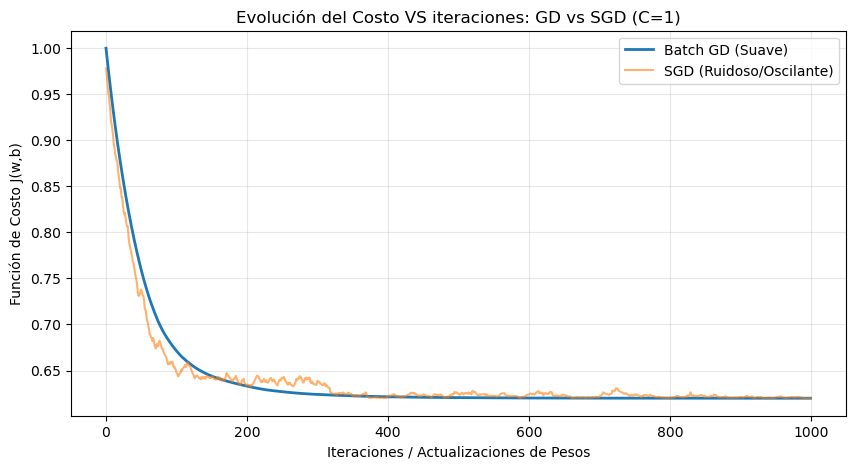

In [8]:
# --- Curva de Costo: GD vs SGD ---
plt.figure(figsize=(10, 5))
# Graficamos los primeros 1000 pasos de ambos
plt.plot(costo_gd[:1000], label='Batch GD (Suave)', linewidth=2)
plt.plot(costo_sgd[:1000], label='SGD (Ruidoso/Oscilante)', alpha=0.6)
plt.title("Evolución del Costo VS iteraciones: GD vs SGD (C=1)")
plt.xlabel("Iteraciones / Actualizaciones de Pesos")
plt.ylabel("Función de Costo J(w,b)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()



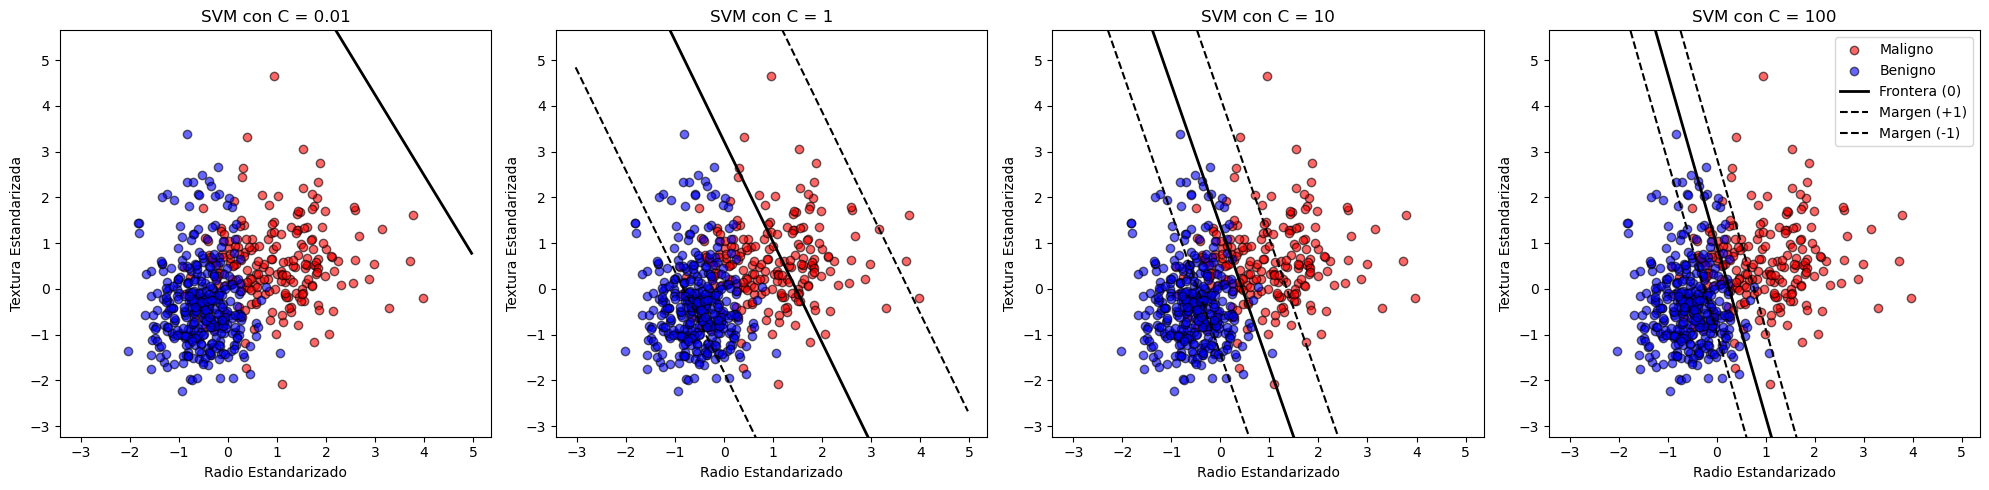

In [9]:
# --- 4(b) y 4(c) Efecto Geométrico de C ---
valores_C = [0.01, 1, 10, 100]
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for i, C_val in enumerate(valores_C):
    # Entrenamos un modelo GD para cada C
    w_opt, b_opt, _ = gradient_descent(X, y, C=C_val, epochs=1500)
    
    ax = axes[i]
    # Scatter plot de los datos
    ax.scatter(X[y==-1, 0], X[y==-1, 1], color='red', label='Maligno', alpha=0.6, edgecolors='k')
    ax.scatter(X[y==1, 0], X[y==1, 1], color='blue', label='Benigno', alpha=0.6, edgecolors='k')
    
    # Generamos la línea de la Frontera de Decisión y los Márgenes
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x1_plot = np.array([x1_min, x1_max])
    
    # Ecuación de la recta: w1*x1 + w2*x2 + b = 0 => x2 = (-w1*x1 - b) / w2
    x2_decis = (-w_opt[0] * x1_plot - b_opt) / w_opt[1]
    x2_margen_pos = (1 - w_opt[0] * x1_plot - b_opt) / w_opt[1]
    x2_margen_neg = (-1 - w_opt[0] * x1_plot - b_opt) / w_opt[1]
    
    ax.plot(x1_plot, x2_decis, 'k-', linewidth=2, label='Frontera (0)')
    ax.plot(x1_plot, x2_margen_pos, 'k--', label='Margen (+1)')
    ax.plot(x1_plot, x2_margen_neg, 'k--', label='Margen (-1)')
    
    ax.set_title(f"SVM con C = {C_val}")
    ax.set_xlabel("Radio Estandarizado")
    ax.set_ylabel("Textura Estandarizada")
    ax.set_ylim(X[:, 1].min() - 1, X[:, 1].max() + 1)

axes[3].legend(loc='upper right')
plt.tight_layout()
plt.show()

### 5. Reflexión Clínica y Computacional

* 5.1. 

     Sí, la curva del SGD presenta altas oscilaciones ("ruido"). Esto se debe a que calcula la dirección de descenso basándose en la "opinión" de un solo paciente a la vez, ignorando la tendencia global del dataset.

     ¿Por qué es indispensable clínicamente? Si tuviéramos un millón de imágenes, cargar la matriz completa para calcular un solo paso del Batch GD desbordaría la memoria RAM de la computadora y tomaría horas. El SGD permite actualizar el modelo inmediatamente analizando imagen por imagen, asegurando una escalabilidad infinita


* 5.2.

    Efecto de la Constante C en el Margen:

    Geométricamente, un C muy bajo (C=0.01) significa que no nos importa penalizar los errores; el modelo prefiere un margen muy ancho (bandas separadas) aunque muchos puntos queden dentro. Al subir a C=100, el castigo es tan brutal que el modelo aprieta y estrecha el margen al máximo intentando que ningún punto lo cruce.

    Generalización clínica: Un C=100 sufre de sobreajuste (overfitting), memorizando ruido. Para futuros pacientes, un valor moderado (C=1 o C=10) generalizará mejor, asumiendo un balance saludable entre un buen margen y tolerancia biológica al solapamiento.


* 5.3.

    Los Vectores de Soporte en la Gráfica:

    Los vectores de soporte son exclusivamente aquellos puntos que están tocando las líneas punteadas (los bordes del margen) o los que se adentraron en la zona prohibida (cruzaron el margen). El resto de los puntos que están seguros en sus respectivas zonas no son vectores de soporte.


* 5.4.

     Matemáticamente, si un punto está fuera del margen correctamente, la función max(0, negativo) se vuelve exactamente 0. Su derivada local es cero absoluto. Por ende, su contribución a la sumatoria del gradiente desaparece. ¡El algoritmo puede ignorar matemáticamente el 90% de los datos fáciles y centrarse solo en la frontera problemática!





